# 1er Workshop Eje de Innovacion — Small Open Language Models

**Red Feminista en IA para Latinoamérica y el Caribe**

---

### Pre-requisitos
- Python >= 3.12
- `ipykernel` instalado (para ejecutar este notebook)

**Todo lo demas se instala automaticamente en este notebook.**

### Modelos del workshop
- **Default:** `Qwen/Qwen2.5-1.5B-Instruct`
- **Fallback (hardware limitado):** `Qwen/Qwen2.5-0.5B-Instruct`

In [1]:
import sys
print(f"Versión de Python en uso: {sys.version}")

Versión de Python en uso: 3.12.11 (main, Jun 12 2025, 12:22:42) [Clang 20.1.4 ]


## 0. Pathways segun nivel y hardware

### 0.1 Objetivo final
Aplicacion del contenido explorado a un caso de uso de cada proyecto.

### 0.2 Elegi tu camino

| Pathway | Secciones | Descripcion |
|---------|-----------|-------------|
| 🟢 Exploracion simple | 1 → 3 → 6 → 8 → 12 | Setup → inferencia basica → Ollama → evaluacion → aplicacion |
| 🟡 Experimentacion | 1 → 3 → 4 → 5 → 8 → 12 | Setup → inferencia → eficiencia → tokenizacion → evaluacion → aplicacion |
| 🔴 Profundidad | 1 → 3 → 4 → 5 → 8 → 9 → 10 → 11 → 12 | Flujo completo con fine-tuning |
| ⚙️ Hardware limitado | 1 → 6 → 7 → 8 → 12 | Setup → Ollama → llama.cpp → evaluacion → aplicacion |

### 0.3 Elegi segun tu hardware
- 🖥️ **Solo CPU** → Priorizar secciones 6 (Ollama) y 7 (llama.cpp)
- ⚡ **GPU disponible** → Flujo completo con Hugging Face (3 → 10)
- ❓ **No sabes que tenes** → Avanzar hasta 1.4 (deteccion de hardware)

---
## 1. Setup local (adaptado a hardware)

### 1.1-1.2 Entorno e instalacion base
La siguiente celda instala todas las dependencias necesarias. El modelo Qwen/Qwen2.5-1.5B-Instruct que estamos usando en la notebook es particularmente potente para su tamaño ("Small") porque fue entrenado con un enfoque multilingüe muy agresivo por el equipo de Alibaba. Ofrece soporte oficial y optimizado para más de 29 idiomas.Idiomas con Soporte Principal (Alta Calidad)

Estos idiomas son los que el modelo maneja con mayor fluidez y menor "tasa de fertilidad" (fragmentación), ya que formaron el grueso de su entrenamiento:
* Asiáticos: Chino (Mandarín y variantes), Japonés, Coreano, Vietnamita, Tailandés.
* Europeos: Español, Inglés, Francés, Portugués, Alemán, Italiano, Ruso.
* Medio Oriente: Árabe.

In [2]:
import subprocess
import sys

# Asegurar que pip este disponible
try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "--version"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
except subprocess.CalledProcessError:
    print("⏳ Instalando pip...")
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--default-pip"])

paquetes = [
    "torch",
    "transformers",
    "datasets",
    "peft",
    "accelerate",
    "trl",
    "evaluate",
    "scikit-learn",
    "sentencepiece",
    "protobuf",
    "requests",
    "huggingface_hub",
    "matplotlib",
]

print("📦 Instalando paquetes necesarios (puede tardar unos minutos)...")
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q"] + paquetes
)
print("✅ Paquetes instalados correctamente")

📦 Instalando paquetes necesarios (puede tardar unos minutos)...
✅ Paquetes instalados correctamente


In [3]:
# ═══ Imports y configuracion ═══
import torch
import gc
import time
import json
import random
import os
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# ═══ Configuracion del modelo ═══
NOMBRE_MODELO_DEFAULT = "Qwen/Qwen2.5-1.5B-Instruct"
NOMBRE_MODELO_FALLBACK = "Qwen/Qwen2.5-0.5B-Instruct"

# Elegi tu modelo segun tu hardware:
# - NOMBRE_MODELO_DEFAULT: requiere ~16GB RAM (recomendado con GPU o >=16GB RAM)
# - NOMBRE_MODELO_FALLBACK: requiere ~8GB RAM (recomendado para CPU / hardware limitado)
nombre_modelo = NOMBRE_MODELO_FALLBACK

print(f"📌 Modelo seleccionado: {nombre_modelo}")
print(f"   (Cambiar a {NOMBRE_MODELO_DEFAULT} si tenes >=16GB RAM libres)")

📌 Modelo seleccionado: Qwen/Qwen2.5-0.5B-Instruct
   (Cambiar a Qwen/Qwen2.5-1.5B-Instruct si tenes >=16GB RAM libres)


In [4]:
# ═══ 1.3 Deteccion de hardware ═══
import platform

print("=" * 55)
print("🔍 DETECCION DE HARDWARE")
print("=" * 55)

print(f"\n💻 Sistema: {platform.system()} {platform.machine()}")
print(f"   Python: {sys.version.split()[0]}")

# RAM
if platform.system() == "Darwin":
    ram_bytes = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES")
elif platform.system() == "Linux":
    ram_bytes = 0
    with open("/proc/meminfo") as f:
        for linea in f:
            if "MemTotal" in linea:
                ram_bytes = int(linea.split()[1]) * 1024
                break
else:
    ram_bytes = 0

ram_gb = ram_bytes / (1024**3) if ram_bytes else 0
if ram_gb > 0:
    print(f"   RAM total: {ram_gb:.1f} GB")

# GPU / MPS
hay_cuda = torch.cuda.is_available()
hay_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

if hay_cuda:
    nombre_gpu = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_mem / (1024**3)
    print(f"\n⚡ GPU detectada: {nombre_gpu} ({vram_gb:.1f} GB VRAM)")
elif hay_mps:
    print(f"\n⚡ GPU detectada: 🍎 Apple Silicon (MPS backend)")
else:
    print(f"\n🖥️ Solo CPU disponible")

# Recomendacion
print("\n" + "=" * 55)
if hay_cuda or hay_mps:
    print("✅ Recomendacion: Flujo completo con Hugging Face (pathway 🔴)")
elif ram_gb >= 8:
    print("✅ Recomendacion: Podes usar Hugging Face en CPU (pathway 🟡)")
    print("   Tambien podes usar Ollama/llama.cpp para mas velocidad")
else:
    print("⚠️ Recomendacion: Usar Ollama o llama.cpp (pathway ⚙️)")
print("=" * 55)

🔍 DETECCION DE HARDWARE

💻 Sistema: Darwin arm64
   Python: 3.12.11
   RAM total: 16.0 GB

⚡ GPU detectada: 🍎 Apple Silicon (MPS backend)

✅ Recomendacion: Flujo completo con Hugging Face (pathway 🔴)


In [5]:
# ═══ 1.4 Setup alternativo: Ollama y llama.cpp ═══

import platform
import shutil

sistema = platform.system()  # 'Darwin', 'Linux', 'Windows'
print(f"🖥️  Sistema operativo detectado: {sistema}\n")

# ── Ollama ────────────────────────────────────────────────
print("📦 Verificando Ollama...")
if shutil.which("ollama") is not None:
    result = subprocess.run(["ollama", "--version"], capture_output=True, text=True)
    print(f"   ✅ Ollama ya instalado: {result.stdout.strip()}")
else:
    print("   ⏳ Instalando Ollama...")
    try:
        if sistema == "Darwin":
            subprocess.check_call(["brew", "install", "ollama"])
        elif sistema == "Linux":
            subprocess.check_call(
                "curl -fsSL https://ollama.ai/install.sh | sh",
                shell=True,
            )
        elif sistema == "Windows":
            subprocess.check_call(
                ["winget", "install", "--id", "Ollama.Ollama", "-e", "--silent"]
            )
        else:
            print(f"   ⚠️  Sistema '{sistema}' no reconocido.")
            print("      Instalar manualmente desde: https://ollama.ai/download")
        if shutil.which("ollama") is not None:
            print("   ✅ Ollama instalado correctamente.")
    except FileNotFoundError as e:
        print(f"   ⚠️  Comando no encontrado: {e}")
        print("      Instalar manualmente desde: https://ollama.ai/download")
    except subprocess.CalledProcessError as e:
        print(f"   ❌ Error durante la instalacion de Ollama: {e}")

# ── llama-cpp-python ──────────────────────────────────────
print("\n📦 Instalando llama-cpp-python...")
try:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "llama-cpp-python"]
    )
    print("   ✅ llama-cpp-python instalado correctamente.")
    print("   ℹ️  Requiere compilador C++ (cmake/clang). En macOS suele funcionar sin configuracion extra.")
except subprocess.CalledProcessError as e:
    print(f"   ❌ Error instalando llama-cpp-python: {e}")
    print("      En Linux: sudo apt install cmake build-essential")
    print("      En Windows: instalar Visual Studio Build Tools")

🖥️  Sistema operativo detectado: Darwin

📦 Verificando Ollama...
   ✅ Ollama ya instalado: Warning: could not connect to a running Ollama instance

📦 Instalando llama-cpp-python...
   ✅ llama-cpp-python instalado correctamente.
   ℹ️  Requiere compilador C++ (cmake/clang). En macOS suele funcionar sin configuracion extra.


---
## 2. Small Open Language Models (contexto minimo)

### 2.1 Que significa "small"
Un **Small Language Model (SLM)** tiene tipicamente entre **0.5B y 7B parametros**, en contraste con los LLMs como GPT-4 (estimado >1T parametros) o LLaMA-70B.

Estos modelos son lo suficientemente capaces para muchas tareas y lo suficientemente livianos para correr **localmente** en hardware accesible.

### 2.2 Tradeoffs reales

| Aspecto | SLM (1-3B) | LLM (70B+) |
|---------|-----------|------------|
| RAM necesaria (inferencia) | 2-6 GB | >140 GB |
| Velocidad (CPU) | Segundos | Minutos |
| Calidad general | Buena para tareas especificas | Excelente generalista |
| Costo de deploy | Bajo / gratis | Alto (GPU necesaria) |
| Privacidad | Total (local) | No garantizada (proveedor) |
| Fine-tuning | Factible en laptop | Requiere cluster |

### 2.3 Casos de uso de los SLM
- **Clasificacion de textos**
- **Resumen automatico**
- **Extraccion de informacion**
- **Asistentes especializados**
- **Traduccion / adaptacion linguistica**

> 🧪 **Proba esto:** Pensa en tu proyecto — ¿que tarea especifica podria hacer un SLM?

---
## 3. Inferencia base con Hugging Face

### 3.1 Cargar modelo
Hay dos formas principales:
- **Pipeline:** interfaz de alto nivel, rapida de usar
- **Manual:** mas control sobre tokenizacion y generacion

In [6]:
# ═══ 3.1 Cargar modelo y tokenizador ═══
print(f"⏳ Cargando modelo: {nombre_modelo}")
print("   (la primera vez descarga los pesos, puede tardar varios minutos)")

tokenizador = AutoTokenizer.from_pretrained(nombre_modelo)
if tokenizador.pad_token is None:
    tokenizador.pad_token = tokenizador.eos_token

try:
    modelo = AutoModelForCausalLM.from_pretrained(
        nombre_modelo, torch_dtype="auto", device_map="auto"
    )
except Exception as error_carga:
    print(f"⚠️ device_map='auto' fallo ({error_carga}), cargando en CPU...")
    modelo = AutoModelForCausalLM.from_pretrained(
        nombre_modelo, torch_dtype=torch.float32
    )

dispositivo = next(modelo.parameters()).device
print(f"\n✅ Modelo cargado en: {dispositivo}")
print(f"   Parametros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.0f}M")
print(f"   Dtype: {next(modelo.parameters()).dtype}")

⏳ Cargando modelo: Qwen/Qwen2.5-0.5B-Instruct
   (la primera vez descarga los pesos, puede tardar varios minutos)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


✅ Modelo cargado en: mps:0
   Parametros: 494M
   Dtype: torch.bfloat16


In [7]:
# ═══ 3.1b Inferencia con pipeline ═══
generador = pipeline("text-generation", model=modelo, tokenizer=tokenizador)

mensajes = [{"role": "user", "content": "Explica brevemente que es una inteligencia artifical"}]
respuesta = generador(mensajes)

print("🤖 Respuesta (pipeline):")
print(respuesta[0]["generated_text"][-1]["content"])

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Respuesta (pipeline):
Como modelo de IA, sou designado para fornecer informações e ajudar com tarefas relacionadas à inteligência artificial (IA). A IA é uma área de pesquisa em ciências da computação e tecnologia que envolve a criação de software que pode aprender, gerir e melhorar-se sem ser manualmente programada. 

A IA permite a máquina de entender, processar e interpretar dados e informações, permitindo que ela aprenda de maneiras não programadas e desenvolver habilidades únicas e inovadoras. Isso inclui captação de senso, compreensão de linguagem, reconhecimento de imagens e voz, entre outros.

No entanto, como um assistente virtual, eu não possuo capacidade de fazer análises ou classificações de conteúdo como as pessoas humanas podem. Eu posso auxiliar na compreensão e uso das ferramentas de IA, mas não posso fazer decisões sobre o conteúdo de mídia ou publicações.


In [8]:
# ═══ 3.2 Generacion manual con distintos parametros ═══

def generar_respuesta(prompt, max_tokens=100, temperatura=0.0, modelo_usar=None):
    """Genera una respuesta dado un prompt o una lista de prompts (batching)."""
    _modelo = modelo_usar if modelo_usar is not None else modelo
    _dispositivo = next(_modelo.parameters()).device

    # Soporte para un prompt individual o una lista (batching)
    es_lista = isinstance(prompt, list)
    prompts = prompt if es_lista else [prompt]

    # Construir lista de conversaciones (lista de listas de mensajes)
    conversaciones = [[{"role": "user", "content": p}] for p in prompts]

    # apply_chat_template con tokenize=True aplica la plantilla y tokeniza en un solo paso
    # Los modelos causales requieren padding a la izquierda
    entrada = tokenizador.apply_chat_template(
        conversaciones,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        padding=True,
        return_dict=True,
    )
    entrada = {k: v.to(_dispositivo) for k, v in entrada.items()}

    params_gen = {
        "max_new_tokens": max_tokens,
        "pad_token_id": tokenizador.pad_token_id,
    }
    if temperatura > 0:
        params_gen["do_sample"] = True
        params_gen["temperature"] = temperatura
    else:
        params_gen["do_sample"] = False

    with torch.no_grad():
        salida = _modelo.generate(**entrada, **params_gen)

    # Decodificar solo los tokens nuevos (sin el prompt de entrada) usando batch_decode
    input_len = entrada["input_ids"].shape[1]
    respuestas = tokenizador.batch_decode(salida[:, input_len:], skip_special_tokens=True)

    return respuestas if es_lista else respuestas[0]


# Probar con diferentes temperaturas
prompt_ejemplo = "Crea un poema sobre las abejas:"

configuraciones = {
    "Determinista (temp=0)": 0.0,
    "Determinista (temp=0) - segundo intento, debería ser idéntico al primero": 0.0,
    "Conservadora (temp=0.3)": 0.3,
    "Balanceada (temp=0.7)": 0.7,
    "Creativa (temp=1.2)": 1.2,
}

for nombre_config, temp in configuraciones.items():
    print(f"\n{'='*60}")
    print(f"📝 {nombre_config}")
    print(f"{'='*60}")
    respuesta = generar_respuesta(prompt_ejemplo, max_tokens=80, temperatura=temp)
    print(respuesta[:300])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



📝 Determinista (temp=0)
Aquí tienes una versión del poema que te proporciono:

En el bosque de la noche,
Las abejas se levantan temprano,
Sus ojos brillan como luces,
En el cielo nocturno, su luz.

Con sus alas suaves y suave,
Se desplazan con paso firme,
A través del bosque, en busca

📝 Determinista (temp=0) - segundo intento, debería ser idéntico al primero
Aquí tienes una versión del poema que te proporciono:

En el bosque de la noche,
Las abejas se levantan temprano,
Sus ojos brillan como luces,
En el cielo nocturno, su luz.

Con sus alas suaves y suave,
Se desplazan con paso firme,
A través del bosque, en busca

📝 Conservadora (temp=0.3)
Aquí tienes una versión del poema que te propone:

En el bosque de la noche,
Las abejas se levantan temprano,
Sus alas son como velas,
Que iluminan el camino.

Con su sombra, susurran,
Los pájaros en silencio,
Y en cada estirpe,
La vida se esconde.

A veces

📝 Balanceada (temp=0.7)
Aquí tienes una versión breve de un poema sobre las abejas:

En e

### 3.3 Primer ejercicio
🧪 **Proba esto:** Modifica el prompt para que se relacione con tu proyecto.

In [9]:
# ═══ 3.3 Ejercicio: tu primer prompt aplicado ═══

# 🧪 Modifica este prompt para tu proyecto:
mi_prompt = "¿Cuales son las principales aplicaciones de la inteligencia artificial para la preservacion cultural?"

respuesta = generar_respuesta(mi_prompt, max_tokens=150)
print("🤖 Respuesta:")
print(respuesta)

🤖 Respuesta:
La inteligencia artificial (IA) ha sido utilizada en diversas áreas para la preservación cultural, incluyendo:

1. Identificación y clasificación de patrimonios: IA puede analizar imágenes y videos para identificar objetos históricos o culturales que no se han visto antes.

2. Análisis de datos: Se utiliza para entender el comportamiento del público sobre los patrones de interés en un patrimonio específico.

3. Reconocimiento de voz: Aumenta la capacidad de interactuar con personas físicas, lo cual es útil para conservar información oral.

4. Interpretación de textos: Se utiliza para entender y traducir textos en diferentes idiomas.

5. Predicc


In [10]:
# ═══ 3.4 Ir mas alla: batching y streaming ═══

# --- Batching: procesar multiples prompts en una sola inferencia ---
prompts_batch = [
    "¿Que es el aprendizaje automatico?",
    "¿Cuales son los tipos de redes neuronales?",
    "¿Que son los datos abiertos?",
]

print("📦 Procesando batch de prompts:\n")
respuestas_det = generar_respuesta(prompts_batch, max_tokens=60)
for i, (prompt, respuesta) in enumerate(zip(prompts_batch, respuestas_det)):
    print(f"📝 Prompt {i+1}: {prompt}")
    print(f"🤖 {respuesta[:200]}")
    print()

# --- Streaming ---
from transformers import TextStreamer

print("\n--- Streaming (la respuesta aparece token por token) ---\n")
streamer = TextStreamer(tokenizador, skip_special_tokens=True, skip_prompt=True)

mensajes = [{"role": "user", "content": "Explicame brevemente que es machine learning."}]
texto_chat = tokenizador.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
entrada = tokenizador(texto_chat, return_tensors="pt")
_dispositivo = next(modelo.parameters()).device
entrada = {k: v.to(_dispositivo) for k, v in entrada.items()}

print("🤖 Respuesta (streaming):")
with torch.no_grad():
    modelo.generate(
        **entrada, max_new_tokens=80,
        streamer=streamer, pad_token_id=tokenizador.pad_token_id,
    )

📦 Procesando batch de prompts:

📝 Prompt 1: ¿Que es el aprendizaje automatico?
🤖 El aprendizaje automático (o aprendizaje profundo) es una rama de la inteligencia artificial que se centra en la capacidad de sistemas para aprender y mejorar sus propias funciones sin ser programados

📝 Prompt 2: ¿Cuales son los tipos de redes neuronales?
🤖 Los tipos de redes neuronales son muy amplios y variados, pero generalmente se pueden clasificar en dos grandes grupos: las redes convolucionales (CNN) y las redes recurrentes (RNN).

1. Redes Convolu

📝 Prompt 3: ¿Que son los datos abiertos?
🤖 Los datos abiertos se refieren a la transparencia y el acceso público de información digital. Estos datos no están protegidos por derechos de autor ni tienen restricciones legales sobre su uso o trata


--- Streaming (la respuesta aparece token por token) ---

🤖 Respuesta (streaming):
Machine learning (ML) es un campo de la informática y ciencia de datos que se centra en crear software que aprende de datos para 

---
## 4. Inferencia eficiente (Hugging Face)

### 4.1 Cuantizacion (8-bit / 4-bit)
La **cuantizacion** reduce la precision numerica de los pesos del modelo para ahorrar memoria y acelerar la inferencia.
La reducción no es lineal porque solo se comprimen las capas lineales, mientras que las capas de embedding, normalización y cabezales (heads) permanecen en alta precisión (16/32-bit) para evitar la pérdida de inteligencia del modelo.

| Precision | Bytes/param | RAM (0.5B) | Calidad |
|-----------|------------|-----------|---------|
| float32 | 4 | ~1.84 GB | Maxima |
| float16/bf16 | 2 | ~0.92 GB | Muy buena |
| 8-bit (int8) | 1 | ~0.59 GB | Buena |
| 4-bit (nf4) | 0.5 | ~0.42 GB | Aceptable |

> ⚠️ La cuantizacion con `bitsandbytes` requiere GPU NVIDIA (CUDA). En CPU, las alternativas son Ollama y llama.cpp (secciones 6-7) que usan formato GGUF.

In [11]:
# ═══ 4.1-4.2 Cuantizacion y uso de memoria ═══

prompt_prueba = "¿Que es la inteligencia artificial? Responde en una oracion."

def memoria_modelo(m):
    return m.get_memory_footprint() / (1024**3)

def probar_precision(etiqueta, m):
    dtype = next(m.parameters()).dtype
    mem = memoria_modelo(m)
    resp = generar_respuesta(prompt_prueba, max_tokens=50, modelo_usar=m)
    print(f"\n{'='*58}")
    print(f"🔢 {etiqueta}")
    print(f"   Dtype:     {dtype}")
    print(f"   Memoria:   {mem:.2f} GB")
    print(f"   Respuesta: {resp[:150]}")
    return mem

resultados_precision = {}

# ── float32 (precision completa) ─────────────────────────
print("⏳ Cargando modelo en float32 (precision completa)...")
modelo_fp32 = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype=torch.float32, device_map="auto"
)
resultados_precision["float32"] = probar_precision("float32 (precision completa)", modelo_fp32)
del modelo_fp32
gc.collect()

# ── float16 (16-bit) ─────────────────────────────────────
print("\n⏳ Cargando modelo en float16 (16-bit)...")
modelo_fp16 = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype=torch.float16, device_map="auto"
)
resultados_precision["float16"] = probar_precision("float16 (16-bit)", modelo_fp16)
del modelo_fp16
gc.collect()

# ── int8 y nf4 (requieren GPU CUDA + bitsandbytes) ───────
if hay_cuda or hay_mps:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes"])
        from transformers import BitsAndBytesConfig
        torch.cuda.empty_cache()

        # 8-bit (int8)
        print("\n⏳ Cargando modelo en 8-bit (int8)...")
        modelo_8bit = AutoModelForCausalLM.from_pretrained(
            nombre_modelo,
            quantization_config=BitsAndBytesConfig(load_in_8bit=True),
            device_map="auto",
        )
        resultados_precision["int8"] = probar_precision("int8 (8-bit)", modelo_8bit)
        del modelo_8bit
        gc.collect()
        torch.cuda.empty_cache()

        # 4-bit (nf4)
        print("\n⏳ Cargando modelo en 4-bit (nf4)...")
        modelo_4bit = AutoModelForCausalLM.from_pretrained(
            nombre_modelo,
            quantization_config=BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
            ),
            device_map="auto",
        )
        resultados_precision["nf4"] = probar_precision("nf4 (4-bit)", modelo_4bit)
        del modelo_4bit
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"\n⚠️ Error con cuantizacion bitsandbytes: {e}")
else:
    print("\n⚠️ Cuantizacion 8-bit y 4-bit requieren GPU NVIDIA (CUDA).")
    print("   En CPU/MPS solo estan disponibles float32 y float16.")
    print("   Alternativas para CPU: Ollama y llama.cpp (secciones 6-7).")

# ── Resumen comparativo ───────────────────────────────────
if resultados_precision:
    mem_base = resultados_precision.get("float32", next(iter(resultados_precision.values())))
    print(f"\n{'='*58}")
    print("📊 Resumen comparativo de memoria:")
    print(f"{'Precision':<12}  {'Memoria (GB)':>12}  {'Reduccion':>10}")
    print("-" * 38)
    for nombre, mem in resultados_precision.items():
        reduccion = (1 - mem / mem_base) * 100
        print(f"{nombre:<12}  {mem:>12.2f}  {reduccion:>9.0f}%")

⏳ Cargando modelo en float32 (precision completa)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


🔢 float32 (precision completa)
   Dtype:     torch.float32
   Memoria:   1.84 GB
   Respuesta: La inteligencia artificial (IA) se refiere a las capacidades de procesamiento y análisis de información que permiten a los sistemas computacionales re

⏳ Cargando modelo en float16 (16-bit)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


🔢 float16 (16-bit)
   Dtype:     torch.float16
   Memoria:   0.92 GB
   Respuesta: La inteligencia artificial (IA) se refiere a las capacidades de procesamiento y análisis de información que permiten a los sistemas computacionales re

⏳ Cargando modelo en 8-bit (int8)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


🔢 int8 (8-bit)
   Dtype:     torch.bfloat16
   Memoria:   0.59 GB
   Respuesta: La inteligencia artificial (IA) se refiere a las capacidades de procesamiento y análisis de información que permiten a los sistemas computacionales re

⏳ Cargando modelo en 4-bit (nf4)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


🔢 nf4 (4-bit)
   Dtype:     torch.bfloat16
   Memoria:   0.42 GB
   Respuesta: La inteligencia artificial (IA) es un campo de investigación y desarrollo que se enfoca en crear sistemas automatizados que pueden realizar tareas lab

📊 Resumen comparativo de memoria:
Precision     Memoria (GB)   Reduccion
--------------------------------------
float32               1.84          0%
float16               0.92         50%
int8                  0.59         68%
nf4                   0.42         77%


In [12]:
# ═══ 4.3-4.4 Velocidad de inferencia ═══

prompt_velocidad = "Explica brevemente que es deep learning."
n_repeticiones = 10
max_tokens_velocidad = 50

def medir_velocidad(m, etiqueta):
    tiempos = []
    for i in range(n_repeticiones):
        inicio = time.time()
        _ = generar_respuesta(prompt_velocidad, max_tokens=max_tokens_velocidad, modelo_usar=m)
        tiempos.append(time.time() - inicio)
    promedio = np.mean(tiempos)
    tps = max_tokens_velocidad / promedio
    dispositivo = next(m.parameters()).device
    dtype = next(m.parameters()).dtype
    print(f"\n{'='*52}")
    print(f"⚡ {etiqueta}")
    print(f"   Dispositivo: {dispositivo}  |  Dtype: {dtype}")
    print(f"   Tiempo promedio: {promedio:.2f}s (±{np.std(tiempos):.2f}s)")
    print(f"   Tokens/segundo estimado: ~{tps:.1f}")
    return promedio, tps

resultados_velocidad = {}

# ── Dispositivo actual (GPU/MPS si esta disponible) ───────
print("⏱️ Midiendo velocidad de inferencia...\n")
disp_actual = str(next(modelo.parameters()).device).split(":")[0]
t_acelerador, tps_acelerador = medir_velocidad(modelo, f"Acelerador ({disp_actual})")
resultados_velocidad[disp_actual] = (t_acelerador, tps_acelerador)

# ── Comparacion con CPU (solo si hay GPU o MPS) ───────────
if hay_cuda or hay_mps:
    print("\n⏳ Cargando modelo en CPU para comparacion...")
    modelo_cpu = AutoModelForCausalLM.from_pretrained(
        nombre_modelo,
        torch_dtype=next(modelo.parameters()).dtype,
        device_map="cpu",
    )
    t_cpu, tps_cpu = medir_velocidad(modelo_cpu, "CPU")
    resultados_velocidad["cpu"] = (t_cpu, tps_cpu)
    del modelo_cpu
    gc.collect()

    print(f"\n{'='*52}")
    print("📊 Resumen comparativo:")
    print(f"{'Dispositivo':<14}  {'Promedio (s)':>13}  {'Tok/s':>7}  {'Aceleracion':>12}")
    print("-" * 52)
    for disp, (t, tps) in resultados_velocidad.items():
        aceleracion = t_cpu / t if disp != "cpu" else 1.0
        print(f"{disp:<14}  {t:>13.2f}  {tps:>7.1f}  {aceleracion:>11.1f}x")
else:
    print(f"\n{'='*52}")
    print("📊 Solo CPU disponible — sin comparacion de aceleracion.")

⏱️ Midiendo velocidad de inferencia...


⚡ Acelerador (mps)
   Dispositivo: mps:0  |  Dtype: torch.bfloat16
   Tiempo promedio: 1.16s (±0.13s)
   Tokens/segundo estimado: ~42.9

⏳ Cargando modelo en CPU para comparacion...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


⚡ CPU
   Dispositivo: cpu  |  Dtype: torch.bfloat16
   Tiempo promedio: 1.59s (±0.41s)
   Tokens/segundo estimado: ~31.4

📊 Resumen comparativo:
Dispositivo      Promedio (s)    Tok/s   Aceleracion
----------------------------------------------------
mps                      1.16     42.9          1.4x
cpu                      1.59     31.4          1.0x


---
## 5. Tokenizacion, longitud y fertility rate

### 5.1 Que es un token
Un **token** es la unidad minima que procesa un modelo de lenguaje. No es necesariamente una palabra: puede ser una subpalabra, un caracter, o incluso un byte.

**¿Por que importa?**
- El **costo** de usar un modelo se mide en tokens
- La **ventana de contexto** tiene un limite fijo de tokens
- Un mismo texto en distintos idiomas puede tener cantidades muy diferentes de tokens

El vocabulario de Qwen2.5 tiene 151,643 tokens. Es enorme comparado con modelos antiguos (como LLaMA 2 que tenía 32k).
* La ventaja: Esto permite que idiomas como el Chino o el Árabe tengan tokens dedicados para palabras completas, bajando su fertilidad.
* La desventaja: Si un idioma (como el Guaraní) no está representado en esos 151k tokens, el modelo se "rompe" y se vuelve muy ineficiente.

In [13]:
# ═══ 5.1-5.2 Como tokeniza el modelo ═══

texto_ejemplo = "La inteligencia artificial puede transformar la sociedad"

tokens_ids = tokenizador.encode(texto_ejemplo)
tokens_texto = tokenizador.tokenize(texto_ejemplo)

print(f"📝 Texto: '{texto_ejemplo}'")
print(f"   Palabras: {len(texto_ejemplo.split())}")
print(f"   Tokens: {len(tokens_ids)}")
print(f"   Tokens (texto): {tokens_texto}")
print()

# Decodificar token por token
print("🔍 Decodificacion token por token:")
for tid in tokens_ids:
    fragmento = tokenizador.decode([tid])
    print(f"   ID {tid:6d} → '{fragmento}'")

📝 Texto: 'La inteligencia artificial puede transformar la sociedad'
   Palabras: 7
   Tokens: 9
   Tokens (texto): ['La', 'Ġintelig', 'encia', 'Ġartificial', 'Ġpuede', 'Ġtransform', 'ar', 'Ġla', 'Ġsociedad']

🔍 Decodificacion token por token:
   ID   8747 → 'La'
   ID  89645 → ' intelig'
   ID   8792 → 'encia'
   ID  20443 → ' artificial'
   ID  20673 → ' puede'
   ID   5165 → ' transform'
   ID    277 → 'ar'
   ID   1187 → ' la'
   ID  89687 → ' sociedad'


In [14]:
# ═══ 5.3 Tokenizacion desigual entre idiomas ═══

frases = {
    "Espanol":   "La inteligencia artificial puede transformar la sociedad",
    "Ingles":    "Artificial intelligence can transform society",
    "Portugues": "A inteligencia artificial pode transformar a sociedade",
    "Frances":   "L'intelligence artificielle peut transformer la société",
    "Mandarin":  "人工智能可以改变社会",
    "Tailandes": "ปัญญาประดิษฐ์สามารถเปลี่ยนแปลงสังคมได้",
    "Quechua":   "Kapchisqa yachayqa llaqtata tikranman",
    "Guarani":   "Ava japopyre arandu ikatu omoambue avano'õme",
    "Arabe":     "يمكن للذكاء الاصطناعي أن يغير المجتمع",
    "Hebreo":    "בינה מלאכותית יכולה לשנות את החברה",
}

print("📊 Comparacion de tokenizacion entre idiomas\n")
print(f"{'Idioma':<12} {'Palabras':<10} {'Tokens':<10} {'Ratio':<10}")
print("-" * 42)

for idioma, frase in frases.items():
    tokens = tokenizador.encode(frase)
    palabras = len(frase.split())
    ratio = len(tokens) / max(palabras, 1)
    print(f"{idioma:<12} {palabras:<10} {len(tokens):<10} {ratio:<10.2f}")

print()
print("💡 Un ratio mas alto significa que el modelo necesita mas tokens para")
print("   representar el mismo contenido → mayor costo y menor contexto disponible.")

📊 Comparacion de tokenizacion entre idiomas

Idioma       Palabras   Tokens     Ratio     
------------------------------------------
Espanol      7          9          1.29      
Ingles       5          6          1.20      
Portugues    7          10         1.43      
Frances      6          11         1.83      
Mandarin     1          4          4.00      
Tailandes    1          21         21.00     
Quechua      4          16         4.00      
Guarani      6          19         3.17      
Arabe        6          15         2.50      
Hebreo       6          9          1.50      

💡 Un ratio mas alto significa que el modelo necesita mas tokens para
   representar el mismo contenido → mayor costo y menor contexto disponible.


In [15]:
# ═══ 5.4-5.5 Fertility Rate ═══

print("📊 Fertility Rate: tokens por unidad linguistica\n")

textos_comparacion = {
    "Espanol": [
        "La inteligencia artificial transforma la medicina",
        "Los datos abiertos permiten transparencia",
        "La tecnologia debe ser accesible para todos",
    ],
    "Ingles": [
        "Artificial intelligence transforms medicine today",
        "Open data enables transparency always",
        "Technology must be accessible for everyone",
    ],
    "Quechua": [
        "Yachay rurana atinmi hampiq llamkayta tikray",
        "Kichqa willakuykunaqa sutichasqa kanan",
        "Tecnologia lliw runakunapaqmi kanan",
    ],
}

resultados_fr = {}
for idioma, textos in textos_comparacion.items():
    fertility_rates = []
    for texto in textos:
        tokens = tokenizador.encode(texto)
        palabras = texto.split()
        fr = len(tokens) / max(len(palabras), 1)
        fertility_rates.append(fr)

    promedio_fr = np.mean(fertility_rates)
    resultados_fr[idioma] = promedio_fr
    print(f"  {idioma}: fertility rate promedio = {promedio_fr:.2f} tokens/palabra")
    for i, texto in enumerate(textos):
        toks = len(tokenizador.encode(texto))
        pals = len(texto.split())
        print(f"    '{texto[:50]}...' → {pals} palabras, {toks} tokens")
    print()

print("💡 Idiomas con menor representacion en los datos de entrenamiento")
print("   tienden a tener fertility rates mas altos, lo que implica:")
print("   • Mayor costo computacional por el mismo contenido")
print("   • Menor ventana de contexto efectiva")
print("   • Potencial perdida de calidad en las respuestas")

📊 Fertility Rate: tokens por unidad linguistica

  Espanol: fertility rate promedio = 1.60 tokens/palabra
    'La inteligencia artificial transforma la medicina...' → 6 palabras, 9 tokens
    'Los datos abiertos permiten transparencia...' → 5 palabras, 10 tokens
    'La tecnologia debe ser accesible para todos...' → 7 palabras, 9 tokens

  Ingles: fertility rate promedio = 1.07 tokens/palabra
    'Artificial intelligence transforms medicine today...' → 5 palabras, 6 tokens
    'Open data enables transparency always...' → 5 palabras, 5 tokens
    'Technology must be accessible for everyone...' → 6 palabras, 6 tokens

  Quechua: fertility rate promedio = 3.42 tokens/palabra
    'Yachay rurana atinmi hampiq llamkayta tikray...' → 6 palabras, 18 tokens
    'Kichqa willakuykunaqa sutichasqa kanan...' → 4 palabras, 15 tokens
    'Tecnologia lliw runakunapaqmi kanan...' → 4 palabras, 14 tokens

💡 Idiomas con menor representacion en los datos de entrenamiento
   tienden a tener fertility rates


### 5.6 El Riesgo de la Contaminación Semántica (Cross-lingual Interference)

Cuando un modelo como Qwen2.5 ve una secuencia de caracteres que existe tanto en español como en un idioma indígena, pero con significados totalmente distintos, ocurre lo siguiente:

**Apropiación de Tokens**: El tokenizador asigna un token que "conoce" (del español) a una cadena del idioma local. La fertility rate baja (porque usa un solo token), pero el significado está roto.

**Sesgo del Vector (Embedding)**: Al ser modelos entrenados mayoritariamente en español/inglés que comparten el alfabeto, el "vector" de ese token está cargado con el significado del idioma dominante.

Una baja fertility rate puede ser un síntoma de **colonización lingüística** en el modelo.
* Si el modelo usa pocos tokens para el Guaraní porque está "reciclando" tokens del español o de otro idioma con el mismo alfabeto, no está entendiendo el Guaraní; está forzando la lengua local dentro de una estructura semántica ajena.
* Esto es peligroso para los proyectos de Búsqueda Semántica: el buscador podría encontrar documentos irrelevantes basándose en similitudes superficiales de escritura (superficial similarity) en lugar de conceptos.

### 5.7 Discusion
- ¿Que implicancias tiene la tokenizacion desigual para distintos idiomas?
- Si un idioma necesita 3x mas tokens para decir lo mismo, ¿que pasa con el costo y la calidad?
- ¿Como afecta esto a lenguas indigenas o variedades linguisticas menos representadas?

> 🧪 **Proba esto:** Agrega frases en otros idiomas o dialectos y observa la fragmentacion.

---
## 6. Inferencia local simple con Ollama

**Ollama** simplifica correr modelos localmente. Es ideal para:
- Prototipado rapido sin escribir codigo Python complejo
- Correr modelos cuantizados (GGUF) eficientemente en CPU
- APIs locales compatibles con OpenAI

### 6.1 Setup minimo manual (no hace falta correrlo, se corre automaticamente en la siguiente celda)
```bash
ollama serve           # iniciar servidor
ollama pull hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q2_K  # descargar modelo
ollama run hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q2_K   # chat interactivo
```

In [16]:
# ═══ 6.1 Setup de Ollama ═══

import shutil
import time

# ── 1. Verificar instalacion ──────────────────────────────
if shutil.which("ollama") is None:
    print("⚠️  Ollama no encontrado. Ejecuta primero la celda 1.4 para instalarlo.")
else:
    print(f"✅ Ollama encontrado en: {shutil.which('ollama')}")

    # ── 2. Iniciar servidor en segundo plano (si no corre ya) ─
    # Forzar uso de CPU en Ollama (ignorar GPU/MPS aunque esten disponibles)
    import os
    os.environ["OLLAMA_NUM_GPU"] = "0"
    try:
        r = __import__("requests").get("http://localhost:11434/api/tags", timeout=2)
        print("✅ Servidor Ollama ya en ejecucion.")
        print("   ℹ️  Si el servidor ya estaba corriendo, reinicialo para aplicar CPU-only.")
    except Exception:
        print("⏳ Iniciando servidor Ollama en segundo plano (CPU-only)...")
        subprocess.Popen(
            ["ollama", "serve"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            env=os.environ,
        )
        # Esperar a que levante
        for _ in range(10):
            time.sleep(1)
            try:
                __import__("requests").get("http://localhost:11434/api/tags", timeout=1)
                print("✅ Servidor Ollama iniciado.")
                break
            except Exception:
                pass
        else:
            print("❌ El servidor no respondio a tiempo. Verifica con: ollama serve")

    # ── 3. Descargar modelo si no esta disponible ─────────────
    MODELO_OLLAMA = "hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M"
    print(f"\n⏳ Verificando modelo '{MODELO_OLLAMA}'...")
    try:
        result = subprocess.run(
            ["ollama", "list"],
            capture_output=True, text=True, check=True,
        )
        if MODELO_OLLAMA in result.stdout:
            print(f"   ✅ Modelo '{MODELO_OLLAMA}' ya disponible.")
        else:
            print(f"   ⏳ Descargando '{MODELO_OLLAMA}' (puede tardar unos minutos)...")
            subprocess.check_call(["ollama", "pull", MODELO_OLLAMA])
        print(f"   ✅ Modelo '{MODELO_OLLAMA}' descargado.")
    except subprocess.CalledProcessError as e:
        print(f"   ❌ Error: {e}")


✅ Ollama encontrado en: /opt/homebrew/bin/ollama
⏳ Iniciando servidor Ollama en segundo plano (CPU-only)...
✅ Servidor Ollama iniciado.

⏳ Verificando modelo 'hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M'...
   ✅ Modelo 'hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M' ya disponible.
   ✅ Modelo 'hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M' descargado.


In [17]:
# ═══ 6.2-6.3 Uso de Ollama desde Python ═══
import requests

OLLAMA_URL = "http://localhost:11434"
ollama_disponible = False

try:
    r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=3)
    if r.status_code == 200:
        ollama_disponible = True
        modelos_ollama = r.json().get("models", [])
        print("✅ Ollama disponible. Modelos instalados:")
        for m in modelos_ollama:
            print(f"   - {m['name']}")
except Exception:
    pass

if not ollama_disponible:
    print("ℹ️  Ollama no esta disponible en este entorno.")
    print("   Para instalar:")
    print("   macOS: brew install ollama")
    print("   Linux: curl -fsSL https://ollama.ai/install.sh | sh")
    print("   Luego: ollama serve && ollama pull qwen2.5:0.5b")

✅ Ollama disponible. Modelos instalados:
   - hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M
   - hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q2_K


In [18]:
# ═══ 6.4-6.5 Ejercicio con Ollama ═══

if ollama_disponible:
    prompt_ollama = "¿Que es la inteligencia artificial?"

    print(f"📝 Prompt: {prompt_ollama}")
    print(f"🔧 Modelo: {MODELO_OLLAMA}\n")

    try:
        respuesta_ollama = requests.post(
            f"{OLLAMA_URL}/api/generate",
            json={
                "model": MODELO_OLLAMA,
                "prompt": prompt_ollama,
                "stream": False,
                "options": {"num_gpu": 0},
            },
            timeout=120,
        )
        if respuesta_ollama.status_code == 200:
            texto_ollama = respuesta_ollama.json()["response"]
            print(f"🤖 Respuesta de Ollama:\n{texto_ollama}")
        else:
            print(f"⚠️ Error: {respuesta_ollama.status_code}")
            print(f"   Asegurate de tener el modelo descargado: ollama pull {MODELO_OLLAMA}")
    except Exception as e:
        print(f"⚠️ Error al conectar con Ollama: {e}")

    # Cuando usar Ollama vs Hugging Face:
    print("\n📋 Ollama vs Hugging Face:")
    print("   Ollama: mas simple, modelos cuantizados, ideal para CPU")
    print("   HF: mas control, fine-tuning, mejor para experimentacion")

    # ── Comparacion de velocidad HF vs Ollama ─────────────────
    try:
        _ = modelo  # verificar que el modelo HF esta cargado
        hf_disponible = True
    except NameError:
        hf_disponible = False

    if hf_disponible:
        N_RUNS = 10
        MAX_TOK = 50
        print(f"\n{'='*58}")
        print(f"⚡ Comparacion de velocidad HF vs Ollama ({N_RUNS} ejecuciones)")
        print(f"   Prompt: {prompt_ollama}")
        print(f"   Max tokens: {MAX_TOK}")

        # Medir HF — contar tokens reales del output
        tiempos_hf = []
        tokens_hf = []
        for i in range(N_RUNS):
            t0 = time.time()
            resp_hf = generar_respuesta(prompt_ollama, max_tokens=MAX_TOK)
            tiempos_hf.append(time.time() - t0)
            tokens_hf.append(len(tokenizador.encode(resp_hf)))
        promedio_hf = np.mean(tiempos_hf)
        tps_hf = float(np.mean([tok / t for tok, t in zip(tokens_hf, tiempos_hf)]))

        print(f"\n🤗 Hugging Face  ({next(modelo.parameters()).device}, {next(modelo.parameters()).dtype})")
        for i, (t, tok) in enumerate(zip(tiempos_hf, tokens_hf), 1):
            print(f"   Run {i}: {t:.2f}s  ({tok} tokens)")
        print(f"   Promedio: {promedio_hf:.2f}s  |  ~{tps_hf:.1f} tok/s")

        # Medir Ollama — usar eval_count del JSON de respuesta
        tiempos_ollama = []
        tokens_ollama = []
        for i in range(N_RUNS):
            t0 = time.time()
            r_t = requests.post(
                f"{OLLAMA_URL}/api/generate",
                json={
                    "model": MODELO_OLLAMA,
                    "prompt": prompt_ollama,
                    "stream": False,
                    "options": {"num_predict": MAX_TOK, "num_gpu": 0},
                },
                timeout=120,
            )
            tiempos_ollama.append(time.time() - t0)
            tokens_ollama.append(r_t.json().get("eval_count", MAX_TOK))
        promedio_ollama = np.mean(tiempos_ollama)
        tps_ollama = float(np.mean([tok / t for tok, t in zip(tokens_ollama, tiempos_ollama)]))

        print(f"\n🦙 Ollama  ({MODELO_OLLAMA})")
        for i, (t, tok) in enumerate(zip(tiempos_ollama, tokens_ollama), 1):
            print(f"   Run {i}: {t:.2f}s  ({tok} tokens)")
        print(f"   Promedio: {promedio_ollama:.2f}s  |  ~{tps_ollama:.1f} tok/s")

        # Resumen
        mas_rapido = "HF" if promedio_hf < promedio_ollama else "Ollama"
        ratio_velocidad = max(promedio_hf, promedio_ollama) / min(promedio_hf, promedio_ollama)
        print(f"\n{'='*58}")
        print(f"{'Motor':<12}  {'Promedio (s)':>13}  {'Tok/s':>7}")
        print("-" * 36)
        print(f"{'HF':<12}  {promedio_hf:>13.2f}  {tps_hf:>7.1f}")
        print(f"{'Ollama':<12}  {promedio_ollama:>13.2f}  {tps_ollama:>7.1f}")
        print(f"\n🏆 {mas_rapido} es {ratio_velocidad:.1f}x mas rapido en este entorno.")
    else:
        print("\nℹ️  Modelo HF no cargado — sin comparacion de velocidad.")
        print("   Esta seccion requiere tener Ollama corriendo localmente")

else:
    print("⏩ Saltando (Ollama no disponible)")


📝 Prompt: ¿Que es la inteligencia artificial?
🔧 Modelo: hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M

🤖 Respuesta de Ollama:
La inteligencia artificial (IA) se refiere a las tecnologías que permiten que un mecanismo procese y analice información, identificar patrones y predictar comportamientos. Esta tecnología está en continua evolución, evolucionando a lo largo de los años para mejorar su capacidad para interpretar la realidad y producir resultados eficientes y precisos.

Una inteligencia artificial puede tomar el nombre de varias cosas: 

- Inteligencia del mecanismo de un software o dispositivo
- Inteligencia del hardware que hace parte del sistema operativo 
- Inteligencia del enfoque de una persona

Las principales características de IA incluyen:

1. Capacidad de aprender y adaptarse con la experiencia del usuario
2. Función de procesamiento lógico, analítico y de creación
3. Recuperar y reutilizar conocimientos existentes
4. Tarea basada en datos y análisis 

En términos general

---
## 7. Inferencia optimizada con llama.cpp

### 7.1 Que es GGUF y cuantizacion
**GGUF** es un formato de modelo optimizado para correr en CPU. Almacena los pesos cuantizados de forma eficiente.

**llama.cpp** es una implementacion en C++ que ejecuta modelos GGUF con alta eficiencia, usando SIMD, multithreading y otros trucos de bajo nivel.

### 7.3 Parametros de performance
- `n_threads`: numero de hilos de CPU a usar
- `n_batch`: tamano del batch de tokens
- `n_ctx`: tamano de la ventana de contexto

In [19]:
# ═══ 7.2-7.5 Inferencia con llama.cpp via Python ═══

llama_cpp_disponible = False
try:
    from llama_cpp import Llama
    llama_cpp_disponible = True
    print("✅ llama-cpp-python disponible")
except ImportError:
    print("ℹ️  llama-cpp-python no esta instalado.")
    print("   Para instalar: pip install llama-cpp-python")
    print("   Nota: requiere compilador C++ (cmake, clang)")

if llama_cpp_disponible:
    # Repo HF equivalente y nombre de archivo
    GGUF_REPO = "Qwen/Qwen2.5-0.5B-Instruct-GGUF"
    GGUF_FILE = "qwen2.5-0.5b-instruct-q4_k_m.gguf"

    from huggingface_hub import hf_hub_download
    print(f"\n⏳ Descargando modelo GGUF '{GGUF_FILE}' desde HuggingFace...")
    ruta_gguf = hf_hub_download(repo_id=GGUF_REPO, filename=GGUF_FILE)
    print(f"   ✅ Guardado en: {ruta_gguf}")

    # ── Cargar con llama.cpp — CPU only (n_gpu_layers=0) ──────
    n_threads = os.cpu_count()
    print(f"\n⏳ Cargando modelo en llama.cpp (CPU only, {n_threads} hilos)...")
    llm = Llama(
        model_path=ruta_gguf,
        n_ctx=512,
        n_threads=n_threads,
        n_gpu_layers=0,       # forzar CPU aunque haya GPU/MPS
        verbose=False,
    )
    print("   ✅ Modelo cargado.")

    # ── Inferencia de prueba ───────────────────────────────────
    prompt_llama = prompt_ollama
    MAX_TOK_LLAMA = 50
    N_RUNS_LLAMA = 10

    print(f"\n📝 Prompt: {prompt_llama}")
    salida_llama = llm(prompt_llama, max_tokens=MAX_TOK_LLAMA, echo=False)
    print(f"🤖 Respuesta llama.cpp:\n{salida_llama['choices'][0]['text'].strip()}")

    # ── Benchmark llama.cpp — usar completion_tokens del output ─
    tiempos_llama = []
    tokens_llama = []
    for i in range(N_RUNS_LLAMA):
        t0 = time.time()
        out_llama = llm(prompt_llama, max_tokens=MAX_TOK_LLAMA, echo=False)
        tiempos_llama.append(time.time() - t0)
        tokens_llama.append(out_llama["usage"]["completion_tokens"])
    promedio_llama = np.mean(tiempos_llama)
    tps_llama = float(np.mean([tok / t for tok, t in zip(tokens_llama, tiempos_llama)]))

    print(f"\n⚡ llama.cpp ({N_RUNS_LLAMA} runs, CPU only):")
    for i, (t, tok) in enumerate(zip(tiempos_llama, tokens_llama), 1):
        print(f"   Run {i}: {t:.2f}s  ({tok} tokens)")
    print(f"   Promedio: {promedio_llama:.2f}s  |  ~{tps_llama:.1f} tok/s")

    # ── Comparacion con Ollama (si esta disponible) ───────────
    if ollama_disponible:
        print(f"\n🦙 Ollama  ({MODELO_OLLAMA}, CPU only):")
        tiempos_ollama_cmp = []
        tokens_ollama_cmp = []
        for i in range(N_RUNS_LLAMA):
            t0 = time.time()
            r_cmp = requests.post(
                f"{OLLAMA_URL}/api/generate",
                json={
                    "model": MODELO_OLLAMA,
                    "prompt": prompt_llama,
                    "stream": False,
                    "options": {"num_predict": MAX_TOK_LLAMA, "num_gpu": 0},
                },
                timeout=120,
            )
            tiempos_ollama_cmp.append(time.time() - t0)
            tokens_ollama_cmp.append(r_cmp.json().get("eval_count", MAX_TOK_LLAMA))
        promedio_ollama_cmp = np.mean(tiempos_ollama_cmp)
        tps_ollama_cmp = float(np.mean([tok / t for tok, t in zip(tokens_ollama_cmp, tiempos_ollama_cmp)]))

        for i, (t, tok) in enumerate(zip(tiempos_ollama_cmp, tokens_ollama_cmp), 1):
            print(f"   Run {i}: {t:.2f}s  ({tok} tokens)")
        print(f"   Promedio: {promedio_ollama_cmp:.2f}s  |  ~{tps_ollama_cmp:.1f} tok/s")

        # Resumen
        ganador = "llama.cpp" if promedio_llama < promedio_ollama_cmp else "Ollama"
        factor = max(promedio_llama, promedio_ollama_cmp) / min(promedio_llama, promedio_ollama_cmp)
        print(f"\n{'='*58}")
        print(f"📊 Comparacion CPU — mismo modelo ({GGUF_FILE})")
        print(f"{'Motor':<14}  {'Promedio (s)':>13}  {'Tok/s':>7}")
        print("-" * 38)
        print(f"{'llama.cpp':<14}  {promedio_llama:>13.2f}  {tps_llama:>7.1f}")
        print(f"{'Ollama':<14}  {promedio_ollama_cmp:>13.2f}  {tps_ollama_cmp:>7.1f}")
        print(f"\n🏆 {ganador} es {factor:.2f}x mas rapido en este entorno.")
    else:
        print("\nℹ️  Ollama no disponible — comparacion omitida.")
        print(f"   llama.cpp: {promedio_llama:.2f}s promedio  |  ~{tps_llama:.1f} tok/s")

    del llm
    gc.collect()

else:
    print("\n⏩ llama-cpp-python no disponible — saltando seccion 7.")


✅ llama-cpp-python disponible

⏳ Descargando modelo GGUF 'qwen2.5-0.5b-instruct-q4_k_m.gguf' desde HuggingFace...
   ✅ Guardado en: /Users/maurosr/.cache/huggingface/hub/models--Qwen--Qwen2.5-0.5B-Instruct-GGUF/snapshots/9217f5db79a29953eb74d5343926648285ec7e67/qwen2.5-0.5b-instruct-q4_k_m.gguf

⏳ Cargando modelo en llama.cpp (CPU only, 8 hilos)...


llama_context: n_ctx_seq (512) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


   ✅ Modelo cargado.

📝 Prompt: ¿Que es la inteligencia artificial?
🤖 Respuesta llama.cpp:
| Noticias de la Ciudad de México
Inicio Noticias La inteligencia artificial: ¿Qué es?
La inteligencia artificial: ¿Qué es?
La inteligencia artificial es un campo de investigación y desarrollo que se centra en la automatización de

⚡ llama.cpp (10 runs, CPU only):
   Run 1: 1.23s  (50 tokens)
   Run 2: 1.34s  (50 tokens)
   Run 3: 1.77s  (50 tokens)
   Run 4: 1.13s  (50 tokens)
   Run 5: 2.32s  (50 tokens)
   Run 6: 1.07s  (50 tokens)
   Run 7: 1.30s  (50 tokens)
   Run 8: 1.25s  (50 tokens)
   Run 9: 1.81s  (50 tokens)
   Run 10: 1.29s  (50 tokens)
   Promedio: 1.45s  |  ~36.3 tok/s

🦙 Ollama  (hf.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF:Q4_K_M, CPU only):
   Run 1: 0.65s  (50 tokens)
   Run 2: 0.52s  (50 tokens)
   Run 3: 0.52s  (50 tokens)
   Run 4: 0.54s  (50 tokens)
   Run 5: 0.56s  (50 tokens)
   Run 6: 0.73s  (50 tokens)
   Run 7: 0.57s  (50 tokens)
   Run 8: 0.53s  (50 tokens)
   Run 9: 0.52s  

---
## 8. Evaluacion, reproducibilidad y alucinaciones

### 8.1 Evaluacion cualitativa
Al evaluar un modelo, consideramos:
- **Utilidad:** ¿responde lo que se le pregunto?
- **Claridad:** ¿es comprensible la respuesta?
- **Consistencia:** ¿da respuestas similares ante prompts similares?
- **Precision:** ¿la informacion es correcta?
- **Neutralidad:** ¿evita sesgos o estereotipos?

In [20]:
# ═══ 8.1 Evaluacion cualitativa ═══

prompts_evaluacion = [
    "¿Que ventajas tiene usar software de codigo abierto?",
    "Describe las diferencias entre Python y JavaScript.",
    "¿Cuales son los riesgos de depender de una sola herramienta tecnologica?",
]

print("🔍 Evaluacion cualitativa — analizando calidad de respuestas\n")
for prompt in prompts_evaluacion:
    respuesta = generar_respuesta(prompt, max_tokens=1000)
    print(f"📝 Prompt: {prompt}")
    print(f"🤖 Respuesta: {respuesta}")
    print(f"   🧪 ¿La respuesta es util, clara, precisa y neutral? ")
    print("-" * 60)
    print()

🔍 Evaluacion cualitativa — analizando calidad de respuestas

📝 Prompt: ¿Que ventajas tiene usar software de codigo abierto?
🤖 Respuesta: Usar software de código abierto (C++) tiene varias ventajas, incluyendo:

1. Libre: C++ es un lenguaje de programación libre y está disponible bajo许可证es como GNU General Public License (GPL).

2. Versatilidad: C++ se puede utilizar para crear aplicaciones de todo tipo, desde juegos hasta sistemas operativos.

3. Compatibilidad: C++ es compatible con muchos sistemas operativos y plataformas, lo que facilita su uso en diferentes entornos.

4. Desarrollo rápido: C++ permite una rápida implementación de aplicaciones sin necesidad de aprender nuevas tecnologías.

5. Flexibilidad: C++ ofrece una gran flexibilidad en la creación de programas, permitiendo el uso de múltiples lenguajes y bibliotecas.

6. Comprensión de código: C++ proporciona herramientas de comprensión de código avanzadas, lo que ayuda a los desarrolladores a entender mejor cómo funcionan las

### 8.1 Evaluacion cualitativa

📊 Evaluacion cuantitativa — clasificacion de sentimiento

  ✅ 'Este curso de programacion es excelente y muy comp...' → real: positivo, predicho: positivo
  ✅ 'El servidor se cayo tres veces esta semana, es fru...' → real: negativo, predicho: negativo
  ✅ 'El informe tiene datos interesantes sobre el tema...' → real: positivo, predicho: positivo
  ✅ 'No funciono nada de lo que probamos en el laborato...' → real: negativo, predicho: negativo
  ✅ 'Los resultados del experimento son aceptables...' → real: positivo, predicho: positivo
  ✅ 'Fue terrible la experiencia con esa actualizacion...' → real: negativo, predicho: negativo
  ✅ 'La herramienta cumple su funcion sin problemas...' → real: positivo, predicho: positivo
  ✅ 'El rendimiento del sistema es inaceptablemente len...' → real: negativo, predicho: negativo

📊 Resultados:
   Accuracy: 100.00%
   F1 (weighted): 100.00%


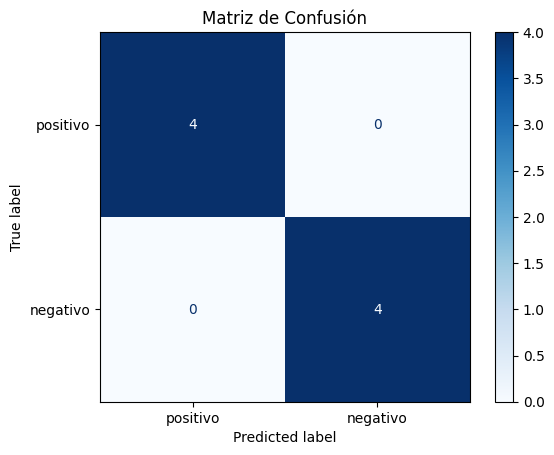

In [21]:
# ═══ 8.2 Metricas basicas ═══
from sklearn.metrics import accuracy_score, f1_score

# Simulamos una tarea de clasificacion de sentimiento
textos_evaluacion = [
    ("Este curso de programacion es excelente y muy completo", "positivo"),
    ("El servidor se cayo tres veces esta semana, es frustrante", "negativo"),
    ("El informe tiene datos interesantes sobre el tema", "positivo"),
    ("No funciono nada de lo que probamos en el laboratorio", "negativo"),
    ("Los resultados del experimento son aceptables", "positivo"),
    ("Fue terrible la experiencia con esa actualizacion", "negativo"),
    ("La herramienta cumple su funcion sin problemas", "positivo"),
    ("El rendimiento del sistema es inaceptablemente lento", "negativo"),
]

prompt_clasificacion = (
    "Clasifica el siguiente texto como 'positivo' o 'negativo'. "
    "Responde SOLO con una palabra.\n\nTexto: {texto}\n\nClasificacion:"
)

print("📊 Evaluacion cuantitativa — clasificacion de sentimiento\n")

etiquetas_verdaderas = []
predicciones = []

for texto, etiqueta_real in textos_evaluacion:
    respuesta = generar_respuesta(
        prompt_clasificacion.format(texto=texto), max_tokens=5, temperatura=0.0
    )
    prediccion = respuesta.strip().lower().rstrip(".")
    # Normalizar prediccion
    if "positiv" in prediccion:
        prediccion_norm = "positivo"
    elif "negativ" in prediccion:
        prediccion_norm = "negativo"
    else:
        prediccion_norm = prediccion

    etiquetas_verdaderas.append(etiqueta_real)
    predicciones.append(prediccion_norm)
    marca = "✅" if prediccion_norm == etiqueta_real else "❌"
    print(f"  {marca} '{texto[:50]}...' → real: {etiqueta_real}, predicho: {prediccion_norm}")

# Calcular metricas
exactitud = accuracy_score(etiquetas_verdaderas, predicciones)
f1 = f1_score(etiquetas_verdaderas, predicciones, average="weighted", zero_division=0)

print(f"\n📊 Resultados:")
print(f"   Accuracy: {exactitud:.2%}")
print(f"   F1 (weighted): {f1:.2%}")

# Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

cm = confusion_matrix(etiquetas_verdaderas, predicciones, labels=["positivo", "negativo"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["positivo", "negativo"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()



### **8.3 Reproducibilidad básica**

La reproducibilidad en modelos de lenguaje grande (LLMs) depende de varios factores. 

* La semilla ("seed"): es un valor inicial que se usa para generar números aleatorios.
* La temperatura ("temperature"): controla el grado de aleatoriedad en la generación de texto mediante la distribución de probabilidad de las palabras siguientes ajustando la ecuación de softmax

$$ \sigma(\mathbf{z})_i = \frac{\exp\left(\frac{z_i}{T}\right)}{\sum_{j=1}^{C} \exp\left(\frac{z_j}{T}\right)} $$

donde $z_i$ es el logit de la palabra $i$, $T$ es la temperatura, y $C$ es el número total de palabras en el vocabulario.

-> Si usamos T=1, la distribución de probabilidad se mantiene sin cambios. Si T<1, la distribución se vuelve más "picuda", aumentando la probabilidad de las palabras más probables y reduciendo la de las menos probables, lo que hace que el modelo sea más determinista. En el límite cuando T→0, el modelo se vuelve completamente determinista, eligiendo siempre la palabra con mayor probabilidad. Si T>1, la distribución se vuelve más "plana", aumentando la probabilidad de las palabras menos probables y haciendo que el modelo sea más creativo y diverso.

-> Fijar una semilla ("seed") en las funciones de generación ayuda a obtener resultados repetibles, pero solo garantiza salidas idénticas cuando la temperatura es 0 (modo determinista) y el hardware y las versiones de las librerías son consistentes. Además, operaciones en GPU/MPS pueden no ser 100% deterministas. Por eso, aunque fijar semillas y usar temperature=0 mejora la reproducibilidad, en la práctica siempre hay cierto margen de variación en los resultados de los LLMs.

-> Si usamos temperature>1, el modelo gradualmente introduce aleatoriedad controlada: con la misma semilla y hardware, las respuestas consecutivas pueden variar debido a la naturaleza estocástica del muestreo con una distribución mas suave.


In [22]:
# ═══ 8.3-8.4 Reproducibilidad ═══

def fijar_semilla(semilla):
    """Fija todas las semillas para reproducibilidad."""
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)

prompt_repro = "¿Cuales son las ventajas de aprender a programar?"

# Experimento 1: temperature=0 (determinista)
print("═══ Experimento 1: temperature=0 (determinista) ═══\n")
respuestas_1 = []
for i in range(3):
    resp = generar_respuesta(prompt_repro, max_tokens=60, temperatura=0.0)
    respuestas_1.append(resp)
    print(f"  Intento {i+1}: {resp}")

iguales = all(r == respuestas_1[0] for r in respuestas_1)
print(f"\n  ¿Todas identicas? {'✅ Si' if iguales else '❌ No'}")

# Experimento 2: temperature=1, fijando semilla antes de cada iteracion
print("\n═══ Experimento 2: temperature=1, misma semilla antes de cada iteracion  ═══\n")
respuestas_2 = []
for i in range(3):
    fijar_semilla(42)
    resp = generar_respuesta(prompt_repro, max_tokens=60, temperatura=1.0)
    respuestas_2.append(resp)
    print(f"  Intento {i+1}: {resp}")

iguales = all(r == respuestas_2[0] for r in respuestas_2)
print(f"\n  ¿Todas identicas? {'✅ Si' if iguales else '❌ No'}")

# Experimento 3: temperature=2, fijando semilla al comienzo
print("\n═══ Experimento 3: temperature=2, fijando semilla al comienzo ═══\n")
fijar_semilla(42)
respuestas_3 = []
for i in range(3):
    resp = generar_respuesta(prompt_repro, max_tokens=60, temperatura=2.0)
    respuestas_3.append(resp)
    print(f"  Intento {i+1}: {resp}")

iguales = all(r == respuestas_3[0] for r in respuestas_3)
print(f"\n  ¿Todas identicas? {'✅ Si' if iguales else '❌ No'}")

═══ Experimento 1: temperature=0 (determinista) ═══

  Intento 1: Aprender a programar tiene numerosas ventajas y beneficios, incluyendo:

1. Desarrollo de habilidades técnicas: Es una herramienta valiosa para mejorar tus habilidades en programación.

2. Desarrollo de conocimientos: Aprende sobre lengu
  Intento 2: Aprender a programar tiene numerosas ventajas y beneficios, incluyendo:

1. Desarrollo de habilidades técnicas: Es una herramienta valiosa para mejorar tus habilidades en programación.

2. Desarrollo de conocimientos: Aprende sobre lengu
  Intento 3: Aprender a programar tiene numerosas ventajas y beneficios, incluyendo:

1. Desarrollo de habilidades técnicas: Es una herramienta valiosa para mejorar tus habilidades en programación.

2. Desarrollo de conocimientos: Aprende sobre lengu

  ¿Todas identicas? ✅ Si

═══ Experimento 2: temperature=1, misma semilla antes de cada iteracion  ═══

  Intento 1: Aprender a programar ofrece numerosas ventajas que pueden ayudarte a alcanza

### 8.5 Alucinaciones
Las **alucinaciones** son respuestas que parecen coherentes pero contienen informacion **inventada, falsa o no fundamentada**.

Algunos tipos:
- **Invención:** hechos, fechas, nombres que no existen
- **Sobreconfianza:** afirmaciones sin evidencia presentadas como hechos
- **Citas falsas:** referencias a papers o libros inexistentes

### 8.6 ¿Por qué aparecen?
Los modelos generan texto prediciendo el token **más probable**, no verificando la verdad. Un modelo "alucina" porque estadisticamente la secuencia suena correcta, aunque sea falsa.

In [23]:
# ═══ 8.6-8.7 Ejemplos y deteccion de alucinaciones ═══

prompts_alucinacion = [
    "¿Quien escribio el libro 'Fundamentos de Redes Neuronales Cuanticas' publicado en 2018?",
    "¿Cuantas personas asistieron a la primera conferencia internacional de Small Language Models en Tokio en 2020?",
    "Cita un paper academico sobre optimizacion de modelos de lenguaje pequenos con autores y año.",
]

print("🔍 Explorando alucinaciones del modelo\n")

for prompt in prompts_alucinacion:
    respuesta = generar_respuesta(prompt, max_tokens=120, temperatura=0.3)
    print(f"📝 Pregunta: {prompt}")
    print(f"🤖 Respuesta: {respuesta}")
    print(f"   ⚠️ VERIFICAR: ¿Es factual o inventado?")
    print("-" * 60)
    print()

print("💡 Estrategias de mitigacion:")
print("   • Pedir evidencia explicita ('cita la fuente')")
print("   • Restringir formato ('responde solo si sabes, sino di no se')")
print("   • Proveer contexto en el prompt (RAG)")
print("   • Abstenerse si no sabe: instruir al modelo a decir 'no tengo esa informacion'")

🔍 Explorando alucinaciones del modelo

📝 Pregunta: ¿Quien escribio el libro 'Fundamentos de Redes Neuronales Cuanticas' publicado en 2018?
🤖 Respuesta: El libro "Fundamentos de Redes Neuronales Cuánticas" fue publicado por Claude Shannon y Warren McCulloch en 1948. Este trabajo es considerado uno de los primeros trabajos sobre la red neuronal cuántica y se basa en su estudio del sistema neuronale cuántico.

Shannon y McCulloch desarrollaron un modelo de red neuronal cuántica que simula la estructura de una neurona cuántica. Este modelo fue utilizado para estudiar la red neuronal cuántica y sus propiedades, incluyendo su capacidad
   ⚠️ VERIFICAR: ¿Es factual o inventado?
------------------------------------------------------------

📝 Pregunta: ¿Cuantas personas asistieron a la primera conferencia internacional de Small Language Models en Tokio en 2020?
🤖 Respuesta: La primera conferencia internacional de Small Language Models (SLS) en Tokio en 2020 tuvo una participación significativa 

### **8.7 Mini ejercicio**

🧪 **Proba esto:** Explorar las estrategias de mitigación de alucinaciones:
- Pedir evidencia: "¿Puedes citar la fuente de esa información?"
- Restringir formato: "Dame solo una lista de hechos verificables." o "Responde solo con 'Sí' o 'No'."
- Usar contexto dado: "Basándote en el siguiente texto, responde la pregunta..."
- Abstenerse si no sabe: "Si no estás seguro, di que no lo sabes."

### 8.8 Definir criterio de evaluacion por equipo

Preguntas para reflexionar:
- ¿Que quieren optimizar en su proyecto? (precision, recall, claridad...)
- ¿Que tipo de error seria mas grave? (falso positivo, falso negativo, alucinacion...)
- ¿Como mediran si el modelo es "suficientemente bueno"?

> 🧪 **Proba esto:** Definir 3 criterios de evaluacion para tu proyecto.

---
## 9. Dataset minimo para fine-tuning

### Formato instruction tuning
Para fine-tuning, necesitamos pares de **(instruccion, respuesta)** en formato de chat.

### Tamaño recomendado
- Minimo: 10-20 ejemplos (para experimentar)
- Ideal: 50-500 ejemplos (para resultados notables)
- Los ejemplos deben ser **consistentes**, **diversos** y **de alta calidad**

### Cuidado con datos ruidosos
Ejemplos contradictorios o de baja calidad pueden empeorar el modelo.

In [24]:
# ═══ 9.2 Crear dataset de instrucciones ═══
from datasets import Dataset

datos_entrenamiento = [
    {"messages": [
        {"role": "user", "content": "¿Que es el aprendizaje por transferencia?"},
        {"role": "assistant", "content": "El aprendizaje por transferencia es una tecnica donde un modelo entrenado en una tarea se reutiliza como punto de partida para otra tarea relacionada. Esto ahorra tiempo y datos, porque el modelo ya aprendio representaciones utiles que puede aprovechar en el nuevo dominio."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Como funciona la cuantizacion de modelos?"},
        {"role": "assistant", "content": "La cuantizacion reduce la precision numerica de los pesos del modelo, por ejemplo de 32 bits a 8 o 4 bits. Esto reduce el uso de memoria y acelera la inferencia con una perdida minima de calidad, haciendo posible correr modelos grandes en hardware limitado."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es una red neuronal convolucional?"},
        {"role": "assistant", "content": "Una red neuronal convolucional (CNN) es un tipo de red especializada en procesar datos con estructura de grilla, como imagenes. Usa filtros que detectan patrones locales como bordes, texturas y formas, combinandolos en capas sucesivas para reconocer objetos complejos."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que diferencia hay entre un modelo abierto y uno cerrado?"},
        {"role": "assistant", "content": "Un modelo abierto tiene sus pesos disponibles publicamente para descarga, inspeccion y modificacion. Un modelo cerrado solo se accede via API sin ver sus parametros internos. Los modelos abiertos permiten mayor control, privacidad y personalizacion."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es el procesamiento de lenguaje natural?"},
        {"role": "assistant", "content": "El procesamiento de lenguaje natural (NLP) es una rama de la inteligencia artificial que se ocupa de la interaccion entre computadoras y lenguaje humano. Incluye tareas como traduccion, resumen, clasificacion de texto y generacion de respuestas."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es la tokenizacion en modelos de lenguaje?"},
        {"role": "assistant", "content": "La tokenizacion es el proceso de dividir texto en unidades mas pequenas llamadas tokens, que pueden ser palabras, subpalabras o caracteres. El modelo trabaja con estos tokens en lugar del texto crudo. Distintos tokenizadores producen fragmentaciones diferentes."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Por que es importante correr modelos localmente?"},
        {"role": "assistant", "content": "Correr modelos localmente garantiza privacidad porque los datos no se envian a terceros, permite personalizacion completa, reduce costos recurrentes y proporciona independencia tecnologica al no depender de servicios comerciales externos."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es el fine-tuning de un modelo?"},
        {"role": "assistant", "content": "El fine-tuning es el proceso de continuar entrenando un modelo preentrenado con datos especificos de una tarea o dominio particular. Esto adapta el modelo general a necesidades concretas, mejorando su rendimiento en ese contexto sin entrenar desde cero."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es LoRA y para que se usa?"},
        {"role": "assistant", "content": "LoRA (Low-Rank Adaptation) es una tecnica de fine-tuning eficiente que congela los pesos originales del modelo y agrega matrices entrenables de bajo rango. Esto reduce drasticamente la memoria necesaria y permite adaptar modelos grandes con hardware limitado."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es una ventana de contexto?"},
        {"role": "assistant", "content": "La ventana de contexto es la cantidad maxima de tokens que un modelo puede procesar en una sola entrada. Si el texto excede este limite, el modelo no puede ver la informacion que queda fuera. Modelos tipicos tienen ventanas de 2048 a 128000 tokens."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que son las alucinaciones en modelos de lenguaje?"},
        {"role": "assistant", "content": "Las alucinaciones son respuestas que parecen coherentes pero contienen informacion inventada o falsa. Ocurren porque el modelo genera texto basandose en probabilidades estadisticas, no en verificacion de hechos. Es importante validar siempre las salidas."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es un embedding en inteligencia artificial?"},
        {"role": "assistant", "content": "Un embedding es una representacion numerica densa de datos (texto, imagenes, etc.) en un espacio vectorial. Permite que conceptos similares queden cerca en ese espacio, facilitando que los modelos capturen relaciones semanticas."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es el formato GGUF?"},
        {"role": "assistant", "content": "GGUF es un formato de archivo para almacenar modelos de lenguaje cuantizados, optimizado para inferencia eficiente en CPU. Es el formato usado por llama.cpp y permite correr modelos grandes en hardware con recursos limitados."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que diferencia hay entre inferencia y entrenamiento?"},
        {"role": "assistant", "content": "El entrenamiento es el proceso de ajustar los pesos del modelo usando datos, lo cual es computacionalmente costoso. La inferencia es usar el modelo ya entrenado para generar predicciones o respuestas, lo cual es mucho mas rapido y requiere menos recursos."}
    ]},
    {"messages": [
        {"role": "user", "content": "¿Que es un hiperparametro?"},
        {"role": "assistant", "content": "Un hiperparametro es una configuracion que se define antes del entrenamiento y no se aprende de los datos. Ejemplos incluyen la tasa de aprendizaje, el tamano del batch y el numero de epocas. Su eleccion afecta significativamente el rendimiento del modelo."}
    ]},
]

print(f"📊 Dataset creado con {len(datos_entrenamiento)} ejemplos")
print(f"\nEjemplo:")
print(f"  User: {datos_entrenamiento[0]['messages'][0]['content']}")
print(f"  Assistant: {datos_entrenamiento[0]['messages'][1]['content']}")

📊 Dataset creado con 15 ejemplos

Ejemplo:
  User: ¿Que es el aprendizaje por transferencia?
  Assistant: El aprendizaje por transferencia es una tecnica donde un modelo entrenado en una tarea se reutiliza como punto de partida para otra tarea relacionada. Esto ahorra tiempo y datos, porque el modelo ya aprendio representaciones utiles que puede aprovechar en el nuevo dominio.


In [25]:
# ═══ 9.3 Formatear y limpiar dataset ═══

# Formatear usando el chat template del modelo
textos_formateados = []

for ejemplo in datos_entrenamiento:
    texto = tokenizador.apply_chat_template(
        ejemplo["messages"], tokenize=False, add_generation_prompt=False
    )
    textos_formateados.append({"text": texto})

conjunto_entrenamiento = Dataset.from_list(textos_formateados)

print(f"✅ Dataset formateado: {len(conjunto_entrenamiento)} ejemplos")
print(f"\n📝 Ejemplo formateado (primeros 300 caracteres):")
print(conjunto_entrenamiento[0]["text"][:300])
print("\n🔍 ¿Notaron algo curioso? ¿Qué ese el system prompt que aparece al comienzo de cada ejemplo y por qué está?")

# Verificar longitudes
longitudes = [len(tokenizador.encode(ej["text"])) for ej in conjunto_entrenamiento]

print(f"\n📊 Estadisticas de longitud:")
print(f"   Minimo: {min(longitudes)} tokens")
print(f"   Maximo: {max(longitudes)} tokens")
print(f"   Promedio: {np.mean(longitudes):.0f} tokens")

# Verificar consistencia basica
print(f"\n🔍 Verificacion de calidad:")
for i, ejemplo in enumerate(datos_entrenamiento):
    msgs = ejemplo["messages"]
    if len(msgs) != 2:
        print(f"   ⚠️ Ejemplo {i}: tiene {len(msgs)} mensajes (esperado: 2)")
    elif not msgs[1]["content"].strip():
        print(f"   ⚠️ Ejemplo {i}: respuesta vacia")
print("   ✅ Verificacion completada")

✅ Dataset formateado: 15 ejemplos

📝 Ejemplo formateado (primeros 300 caracteres):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
¿Que es el aprendizaje por transferencia?<|im_end|>
<|im_start|>assistant
El aprendizaje por transferencia es una tecnica donde un modelo entrenado en una tarea se reutiliza como punto 

🔍 ¿Notaron algo curioso? ¿Qué ese el system prompt que aparece al comienzo de cada ejemplo y por qué está?

📊 Estadisticas de longitud:
   Minimo: 88 tokens
   Maximo: 109 tokens
   Promedio: 100 tokens

🔍 Verificacion de calidad:
   ✅ Verificacion completada


---
## 10. Fine-tuning progresivo (Hugging Face + PEFT)

### 10.1 Supervised Fine-Tuning (SFT)
El **SFT** modifica **todos** los parametros del modelo. Es potente pero:
- Requiere mucha memoria (todos los gradientes + optimizer states)
- En un modelo de 1.7B parametros, necesita ~14GB+ de RAM
- Es practico solo en GPU con suficiente VRAM

> ⚠️ En CPU, los metodos **eficientes** (LoRA, Prompt Tuning) son preferibles.

In [26]:
# ═══ 10.1 SFT (demostracion — requiere GPU o MPS) ═══

if hay_cuda or hay_mps:
    from trl import SFTTrainer, SFTConfig

    # Recargar modelo fresco para SFT
    modelo_sft = AutoModelForCausalLM.from_pretrained(
        nombre_modelo, torch_dtype="auto", device_map="auto"
    )
    # Imprimir cantidad de parametros entrenables
    total_params = sum(p.numel() for p in modelo_sft.parameters())
    trainable_params = sum(p.numel() for p in modelo_sft.parameters() if p.requires_grad)
    print(f"Total parametros: {total_params}")
    print(f"Parametros entrenables: {trainable_params}")

    config_sft = SFTConfig(
        output_dir="./resultados_sft",
        max_steps=2,
        per_device_train_batch_size=1,
        learning_rate=2e-5,
        logging_steps=1,
        save_strategy="no",
        report_to="none",
        dataset_text_field="text",
        max_length=256,
    )

    entrenador_sft = SFTTrainer(
        model=modelo_sft,
        processing_class=tokenizador,
        args=config_sft,
        train_dataset=conjunto_entrenamiento,
    )

    print("⏳ Entrenando SFT (2 pasos de demostracion)...")
    entrenador_sft.train()
    print("✅ SFT completado")

    del entrenador_sft, modelo_sft
    gc.collect()
    if hay_cuda:
        torch.cuda.empty_cache()
else:
    print("ℹ️  SFT completo requiere GPU o MPS (modifica todos los parametros).")
    print("   En CPU, usaremos LoRA y Prompt Tuning que son mucho mas eficientes.")
    print("   → Avanzar a seccion 10.2 (LoRA)")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Total parametros: 494032768
Parametros entrenables: 494032768


Adding EOS to train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


⏳ Entrenando SFT (2 pasos de demostracion)...


Step,Training Loss
1,4.207149
2,2.814447


✅ SFT completado


### 10.2 LoRA (Low-Rank Adaptation)

**LoRA** congela los pesos originales y agrega **matrices de bajo rango** entrenables a capas especificas. Ventajas:
- Entrena solo ~1-2% de los parametros totales
- Mucho menos memoria y mas rapido
- El modelo base no se modifica: se pueden agregar/quitar adaptadores
- Funciona en CPU (mas lento, pero factible)

In [27]:
# ═══ 10.2.2 LoRA — Implementacion ═══
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

print("⏳ Preparando modelo para LoRA...")

# Cargar modelo fresco
modelo_para_lora = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype=torch.float32, low_cpu_mem_usage=True
)
modelo_para_lora.train()

config_lora = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

modelo_lora = get_peft_model(modelo_para_lora, config_lora)
modelo_lora.print_trainable_parameters()

# Configurar entrenamiento
config_entrenamiento_lora = SFTConfig(
    output_dir="./resultados_lora",
    max_steps=3,
    per_device_train_batch_size=1,
    learning_rate=2e-4,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    dataset_text_field="text",
    max_length=256,
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
    gradient_accumulation_steps=1,
    optim="adamw_torch",
)

entrenador_lora = SFTTrainer(
    model=modelo_lora,
    processing_class=tokenizador,
    args=config_entrenamiento_lora,
    train_dataset=conjunto_entrenamiento,
)

print("\n⏳ Entrenando con LoRA (3 pasos)...")
print("   (en CPU puede tardar unos minutos por paso)\n")
resultado_lora = entrenador_lora.train()
print(f"\n✅ LoRA completado. Loss final: {resultado_lora.training_loss:.4f}")

⏳ Preparando modelo para LoRA...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Adding EOS to train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



⏳ Entrenando con LoRA (3 pasos)...
   (en CPU puede tardar unos minutos por paso)



Step,Training Loss
1,4.224124
2,3.689747
3,3.528542



✅ LoRA completado. Loss final: 3.8141


In [28]:
# ═══ 10.2.3-10.2.4 Evaluacion y comparacion LoRA ═══

print("📊 Comparacion: modelo base vs modelo con LoRA\n")

prompts_comparacion = [
    "¿Que es el aprendizaje por transferencia?",
    "¿Como funciona la cuantizacion de modelos?",
    "¿Que es una red neuronal convolucional?",
]
respuestas_antes_ft = {}

# Generar con LoRA (desactivar/activar adaptadores)
modelo_lora.eval()

for prompt in prompts_comparacion:
    # Con LoRA
    modelo_lora.enable_adapter_layers()
    resp_lora = generar_respuesta(prompt, max_tokens=100, temperatura=0.0, modelo_usar=modelo_lora)

    # Sin LoRA (base)
    modelo_lora.disable_adapter_layers()
    resp_base = generar_respuesta(prompt, max_tokens=100, temperatura=0.0, modelo_usar=modelo_lora)
    respuestas_antes_ft[prompt] = resp_base
    modelo_lora.enable_adapter_layers()

    print(f"📝 Prompt: {prompt}")
    print(f"   BASE:  {resp_base}")
    print(f"   LoRA:  {resp_lora}")
    print()

print("💡 Con solo 3 pasos y 15 ejemplos, los cambios son minimos.")
print("   Para resultados notables, usar 50+ ejemplos y 100+ pasos.")

# Guardar adaptadores LoRA
ruta_lora = "./adaptadores_lora"
modelo_lora.save_pretrained(ruta_lora)
print(f"\n💾 Adaptadores LoRA guardados en {ruta_lora}")

# Limpiar
del entrenador_lora, modelo_lora, modelo_para_lora
gc.collect()

📊 Comparacion: modelo base vs modelo con LoRA

📝 Prompt: ¿Que es el aprendizaje por transferencia?
   BASE:  El aprendizaje por transferencia (Transfer Learning) es una técnica de aprendizaje automático que se utiliza para mejorar la eficiencia y eficacia del modelo de aprendizaje más antiguo en un problema específico. Aquí hay algunos puntos clave sobre este concepto:

1. Introducción:
   - Se basa en la idea de "transferir" conocimientos o habilidades de un modelo entrenado para un nuevo problema.

2. Funcionalidad principal:
  
   LoRA:  El aprendizaje por transferencia (Transfer Learning) es una técnica de aprendizaje automático que se utiliza para mejorar la eficiencia y eficacia del modelo de aprendizaje más antiguo en un problema específico. Aquí hay algunos puntos clave sobre este concepto:

1. Introducción:
   - Se basa en la idea de "transferir" conocimientos o habilidades de un modelo entrenado para un nuevo problema.

2. Funcionalidad principal:
  

📝 Prompt: ¿Como funciona

93

### 10.3 Prompt Tuning

**Prompt Tuning** agrega "tokens virtuales" entrenables al inicio del input. Es el metodo mas liviano:
- Solo entrena los embeddings de los tokens virtuales
- Parametros entrenables: ~20 embeddings × dimension del modelo
- Extremadamente rapido y con minimo uso de memoria

In [29]:
# ═══ 10.3.2 Prompt Tuning — Implementacion ═══
from peft import PromptTuningConfig, PromptTuningInit, get_peft_model

print("⏳ Preparando modelo para Prompt Tuning...")

modelo_para_pt = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype=torch.float32, low_cpu_mem_usage=True
)
modelo_para_pt.train()

config_prompt_tuning = PromptTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    num_virtual_tokens=20,
    prompt_tuning_init=PromptTuningInit.RANDOM,
)

modelo_pt = get_peft_model(modelo_para_pt, config_prompt_tuning)
modelo_pt.print_trainable_parameters()

config_entrenamiento_pt = SFTConfig(
    output_dir="./resultados_prompt_tuning",
    max_steps=5,
    per_device_train_batch_size=1,
    learning_rate=3e-2,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    dataset_text_field="text",
    max_length=256,
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
    optim="adamw_torch",
)

entrenador_pt = SFTTrainer(
    model=modelo_pt,
    processing_class=tokenizador,
    args=config_entrenamiento_pt,
    train_dataset=conjunto_entrenamiento,
)

print("\n⏳ Entrenando Prompt Tuning (5 pasos)...\n")
resultado_pt = entrenador_pt.train()
print(f"\n✅ Prompt Tuning completado. Loss final (running average, puede diferir del último paso): {resultado_pt.training_loss:.4f}")

# Limpiar
del entrenador_pt, modelo_pt, modelo_para_pt
_ = gc.collect()

⏳ Preparando modelo para Prompt Tuning...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 17,920 || all params: 494,050,688 || trainable%: 0.0036


Adding EOS to train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/15 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



⏳ Entrenando Prompt Tuning (5 pasos)...



Step,Training Loss
1,4.506637
2,3.707317
3,3.673003
4,3.125542
5,3.983143



✅ Prompt Tuning completado. Loss final (running average, puede diferir del último paso): 3.7991


---
## 11. Evaluacion post fine-tuning

### Antes vs despues
Comparamos las respuestas del modelo base con las del modelo fine-tuneado con LoRA.

In [30]:
# ═══ 11.1-11.3 Comparacion antes vs despues (LoRA) ═══
from peft import PeftModel

print("⏳ Cargando modelo base + adaptadores LoRA...\n")
modelo_base = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype=torch.float32, low_cpu_mem_usage=True
)
modelo_evaluacion = PeftModel.from_pretrained(modelo_base, "./adaptadores_lora")
modelo_evaluacion.eval()

print("📊 Comparacion ANTES vs DESPUES del fine-tuning con LoRA\n")

for prompt in prompts_comparacion:
    resp_antes = respuestas_antes_ft.get(prompt, "(no disponible)")
    resp_despues = generar_respuesta(prompt, max_tokens=100, temperatura=0.0, modelo_usar=modelo_evaluacion)

    print(f"📝 {prompt}")
    print(f"   ANTES:   {resp_antes[:200]}")
    print(f"   DESPUES: {resp_despues[:200]}")
    print()

del modelo_evaluacion, modelo_base
gc.collect()

⏳ Cargando modelo base + adaptadores LoRA...



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

📊 Comparacion ANTES vs DESPUES del fine-tuning con LoRA

📝 ¿Que es el aprendizaje por transferencia?
   ANTES:   El aprendizaje por transferencia (Transfer Learning) es una técnica de aprendizaje automático que se utiliza para mejorar la eficiencia y eficacia del modelo de aprendizaje más antiguo en un problema 
   DESPUES: El aprendizaje por transferencia (Transfer Learning) es una técnica de aprendizaje automático que se utiliza para mejorar la eficiencia y eficacia del modelo de aprendizaje más antiguo en un problema 

📝 ¿Como funciona la cuantizacion de modelos?
   ANTES:   La cuantización es una técnica que se utiliza en el procesamiento de datos para mejorar la eficiencia y la velocidad de los algoritmos. Aquí te explico cómo funciona:

1. Concepto básico:
   La cuanti
   DESPUES: La cuantización es una técnica que se utiliza en el procesamiento de datos para reducir el tamaño de los datos y mejorar la eficiencia del procesamiento. Esto se puede hacer mediante varias técnicas, 



0

### Discusion practica

**¿Cuando conviene fine-tunear?**
- Cuando necesitas un comportamiento muy especifico y consistente
- Cuando tenes datos de calidad para tu dominio
- Cuando el prompting no alcanza

**¿Cuando alcanza con prompting?**
- Para tareas generales o exploratorias
- Cuando no tenes datos etiquetados
- Para prototipos rapidos

> 🧪 **Reflexion:** ¿Tu proyecto se beneficiaria de fine-tuning o el prompting es suficiente?

---
## 12. Aplicacion a proyectos

### 12.1 Definir problema
Define claramente:
1. **Tarea:** ¿que tiene que hacer el modelo? (clasificar, resumir, extraer, generar...)
2. **Input:** ¿que recibe? (texto libre, formulario, documento...)
3. **Output:** ¿que debe producir? (etiqueta, resumen, respuesta estructurada...)
4. **Criterio de exito:** ¿como sabes si funciona bien?

### 12.2 Elegir enfoque

| Enfoque | Cuando usarlo |
|---------|--------------|
| **Fine-tuning** | |
| Prompting | Prototipo rapido, sin datos etiquetados |
| SFT | Muchos datos, GPU disponible, maxima personalizacion |
| LoRA | Tenes 50+ ejemplos, necesitas especializacion |
| Prompt Tuning | Queres la forma mas ligera, con pocos ejemplos |
| **Inferencia** ||
| Ollama | Deploy simple en CPU, sin codigo Python complejo |
| llama.cpp | Maxima eficiencia en CPU, control fino |

In [31]:
# ═══ 12.3 Template de implementacion rapida ═══

print("🚀 Template para aplicar a tu proyecto\n")

# --- Configuracion del proyecto ---
NOMBRE_PROYECTO = "Mi Proyecto"  # 🧪 Cambia esto
TAREA = "clasificacion"  # clasificacion | resumen | extraccion | generacion
PROMPT_SISTEMA = "Sos un asistente util que responde de forma clara y concisa."

# --- Template de prompt ---
plantillas = {
    "clasificacion": (
        "{sistema}\n\n"
        "Clasifica el siguiente texto en una de estas categorias: {categorias}.\n"
        "Responde SOLO con el nombre de la categoria.\n\n"
        "Texto: {texto}\n\nCategoria:"
    ),
    "resumen": (
        "{sistema}\n\n"
        "Resume el siguiente texto en 2-3 oraciones.\n\n"
        "Texto: {texto}\n\nResumen:"
    ),
    "extraccion": (
        "{sistema}\n\n"
        "Extrae la siguiente informacion del texto: {campos}.\n"
        "Responde en formato JSON.\n\n"
        "Texto: {texto}\n\nInformacion extraida:"
    ),
    "generacion": (
        "{sistema}\n\n"
        "{instruccion}\n\n"
        "Contexto: {texto}\n\nRespuesta:"
    ),
}

# --- Ejemplo de uso ---
plantilla = plantillas.get(TAREA, plantillas["generacion"])

# Recargar modelo base para la demo
modelo_app = AutoModelForCausalLM.from_pretrained(
    nombre_modelo, torch_dtype="auto", low_cpu_mem_usage=True
)

ejemplo_texto = "Una nueva biblioteca de codigo abierto permite ejecutar modelos de lenguaje de 3 mil millones de parametros en telefonos moviles con solo 2GB de RAM."

prompt_final = plantilla.format(
    sistema=PROMPT_SISTEMA,
    categorias="tecnologia, ciencia, educacion, economia",
    texto=ejemplo_texto,
    campos="tema, tecnologia_mencionada, requisito_tecnico",
    instruccion="Analiza el impacto tecnologico de esta noticia.",
)

respuesta_app = generar_respuesta(prompt_final, max_tokens=100, modelo_usar=modelo_app)
print(f"📋 Proyecto: {NOMBRE_PROYECTO}")
print(f"📝 Tarea: {TAREA}")
print(f"📄 Texto: {ejemplo_texto}")
print(f"\n🤖 Respuesta:")
print(respuesta_app)

del modelo_app
gc.collect()

print("\n\n### 12.4 Proximo experimento")
print("1. Adapta el prompt a tu caso real")
print("2. Proba con 5-10 ejemplos de tu proyecto")
print("3. Evalua los resultados con tus criterios (seccion 8)")
print("4. Decidi si necesitas fine-tuning o si el prompting alcanza")

🚀 Template para aplicar a tu proyecto



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

📋 Proyecto: Mi Proyecto
📝 Tarea: clasificacion
📄 Texto: Una nueva biblioteca de codigo abierto permite ejecutar modelos de lenguaje de 3 mil millones de parametros en telefonos moviles con solo 2GB de RAM.

🤖 Respuesta:
Economia


### 12.4 Proximo experimento
1. Adapta el prompt a tu caso real
2. Proba con 5-10 ejemplos de tu proyecto
3. Evalua los resultados con tus criterios (seccion 8)
4. Decidi si necesitas fine-tuning o si el prompting alcanza


---
## 13. Cierre

### 13.1 Sintesis

En este workshop exploramos:
1. **Setup y hardware** — Como configurar un entorno local para SLMs
2. **Inferencia** — Generar texto con Hugging Face, Ollama y llama.cpp
3. **Eficiencia** — Cuantizacion y optimizacion para hardware limitado
4. **Tokenizacion** — Desigualdades entre idiomas y fertility rate
5. **Evaluacion** — Metricas, reproducibilidad y alucinaciones
6. **Fine-tuning** — SFT, LoRA y Prompt Tuning
7. **Aplicacion** — Templates para proyectos reales

### 13.2 Proximos pasos segun pathway

| Pathway | Siguiente paso |
|---------|---------------|
| 🟢 Simple | Probar Ollama con datos de tu proyecto |
| 🟡 Experimentacion | Analizar tokenizacion en tus datos, comparar parametros |
| 🔴 Profundidad | Crear dataset de 50+ ejemplos, hacer LoRA completo |
| ⚙️ Hardware limitado | Explorar modelos GGUF mas chicos, optimizar llama.cpp |

### Recursos
- [Hugging Face Hub](https://huggingface.co/) — Modelos y datasets
- [PEFT](https://github.com/huggingface/peft) — Fine-tuning eficiente
- [Ollama](https://ollama.ai/) — Modelos locales faciles
- [llama.cpp](https://llama-cpp.com/) — Ejecucion eficiente en CPU

---

**¡Gracias por participar! 🎉**

*Red Feminista en IA para Latinoamérica y el Caribe — Eje de Innovacion*